# STAT 8017B Project 4 — Classification Models
## Financial Analysis Chatbot (Group 4.1)

This notebook trains and evaluates classification models on two tasks:

- **Task A**: Complaint product classification (17 categories)
- **Task B**: Financial sentiment classification (3 classes)

**Models**: Naive Bayes, SVM, Decision Tree, Random Forest, Neural Network (MLP)

**Course methods**: NB (Ch.3), SVM with PCA (Ch.5), Decision Tree & Ensembles (Ch.4), Neural Network (Lecture 8)

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.decomposition import PCA

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

warnings.filterwarnings('ignore')

PROCESSED_DIR = os.path.join('..', 'data', 'processed')
MODEL_DIR = os.path.join('..', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
def evaluate_model(name, model, X_test, y_test, class_names=None):
    """Evaluate a classifier and print metrics + confusion matrix."""
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f'\n{"=" * 50}')
    print(f'{name}')
    print(f'{"=" * 50}')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'F1-score:  {f1:.4f}')
    print(f'\nClassification Report:\n')
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=ax, cmap='Blues',
        display_labels=class_names, xticks_rotation='vertical'
    )
    ax.set_title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return {'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

print('Evaluation function ready.')

Evaluation function ready.


---
## Task A: Complaint Product Classification

Classify bank customer complaints into 17 product categories using Issue + Sub-issue text.

In [3]:
comp = pd.read_csv(os.path.join(PROCESSED_DIR, 'complaints_clean.csv'))
X_comp_tfidf = joblib.load(os.path.join(PROCESSED_DIR, 'complaints_tfidf_matrix.joblib'))
le_product = joblib.load(os.path.join(PROCESSED_DIR, 'complaints_labels.joblib'))

y_comp = comp['product_label'].values
product_names = list(le_product.classes_)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_comp_tfidf, y_comp, test_size=0.2, random_state=42, stratify=y_comp
)

print(f'Complaints: {X_comp_tfidf.shape[0]:,} samples, {X_comp_tfidf.shape[1]} TF-IDF features')
print(f'Train: {X_train_c.shape[0]:,}  |  Test: {X_test_c.shape[0]:,}')
print(f'Product categories ({len(product_names)}): {product_names}')

Complaints: 200,000 samples, 332 TF-IDF features
Train: 160,000  |  Test: 40,000
Product categories (18): ['Bank account or service', 'Checking or savings account', 'Consumer Loan', 'Credit card', 'Credit card or prepaid card', 'Credit reporting', 'Credit reporting, credit repair services, or other personal consumer reports', 'Debt collection', 'Money transfer, virtual currency, or money service', 'Money transfers', 'Mortgage', 'Other financial service', 'Payday loan', 'Payday loan, title loan, or personal loan', 'Prepaid card', 'Student loan', 'Vehicle loan or lease', 'Virtual currency']


### A1. Naive Bayes (Course Ch.3)


Naive Bayes — Complaints
Accuracy:  0.9325
Precision: 0.9288
Recall:    0.9325
F1-score:  0.9284

Classification Report:

                                                                              precision    recall  f1-score   support

                                                     Bank account or service       0.86      1.00      0.93      2340
                                                 Checking or savings account       0.90      0.77      0.83      1512
                                                               Consumer Loan       0.95      0.97      0.96       857
                                                                 Credit card       0.92      0.78      0.84      2421
                                                 Credit card or prepaid card       0.94      0.87      0.90      1777
                                                            Credit reporting       0.93      0.90      0.92      3812
Credit reporting, credit repair services, or other

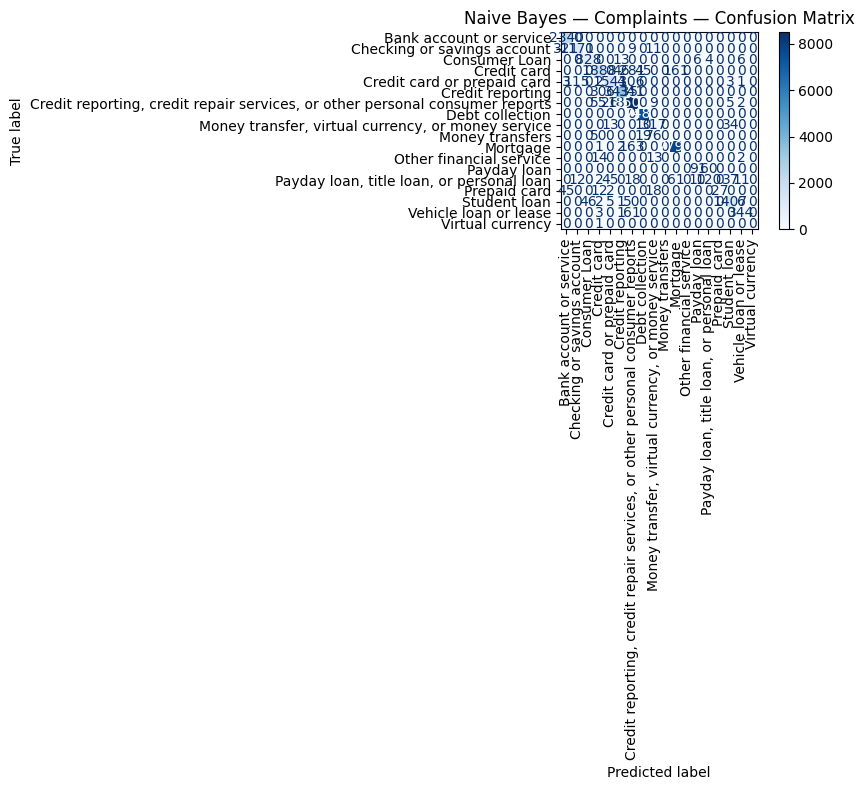

['..\\models\\complaint_nb.joblib']

In [4]:
nb_comp = MultinomialNB(alpha=1.0)
nb_comp.fit(X_train_c, y_train_c)
res_nb = evaluate_model('Naive Bayes — Complaints', nb_comp, X_test_c, y_test_c, product_names)
joblib.dump(nb_comp, os.path.join(MODEL_DIR, 'complaint_nb.joblib'))

### A2. SVM (Course Ch.5)


SVM (LinearSVC) — Complaints
Accuracy:  0.9782
Precision: 0.9791
Recall:    0.9782
F1-score:  0.9765

Classification Report:

                                                                              precision    recall  f1-score   support

                                                     Bank account or service       0.98      1.00      0.99      2340
                                                 Checking or savings account       0.98      0.95      0.96      1512
                                                               Consumer Loan       0.95      0.99      0.97       857
                                                                 Credit card       0.93      1.00      0.96      2421
                                                 Credit card or prepaid card       0.95      0.92      0.93      1777
                                                            Credit reporting       1.00      1.00      1.00      3812
Credit reporting, credit repair services, or o

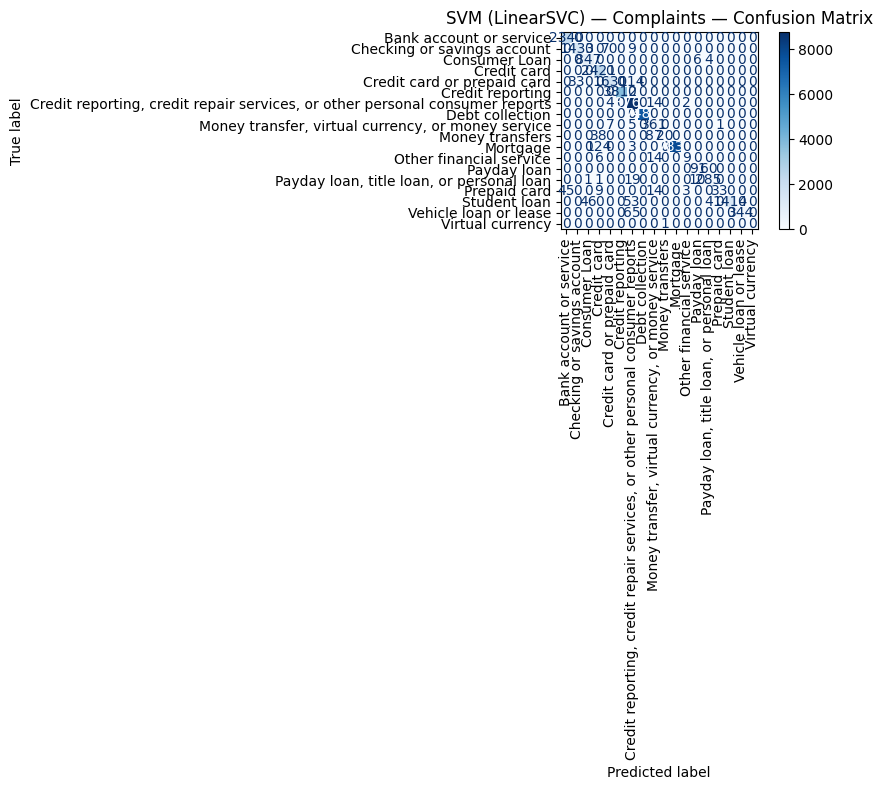

['..\\models\\complaint_svm.joblib']

In [5]:
svm_comp = LinearSVC(C=1.0, max_iter=5000, random_state=42)
svm_comp.fit(X_train_c, y_train_c)
res_svm = evaluate_model('SVM (LinearSVC) — Complaints', svm_comp, X_test_c, y_test_c, product_names)
joblib.dump(svm_comp, os.path.join(MODEL_DIR, 'complaint_svm.joblib'))

### A3. SVM with PCA (Course Ch.5 — dimensionality reduction before classification)

In [ ]:
N_COMPONENTS = 200

pca_comp = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca_comp.fit_transform(X_train_c.toarray())
X_test_pca = pca_comp.transform(X_test_c.toarray())

explained = pca_comp.explained_variance_ratio_.sum()
print(f'PCA: {N_COMPONENTS} components explain {explained:.2%} of variance')

svm_pca = LinearSVC(C=1.0, max_iter=5000, random_state=42)
svm_pca.fit(X_train_pca, y_train_c)
res_svm_pca = evaluate_model('SVM + PCA — Complaints', svm_pca, X_test_pca, y_test_c, product_names)
joblib.dump(svm_pca, os.path.join(MODEL_DIR, 'complaint_svm_pca.joblib'))
joblib.dump(pca_comp, os.path.join(MODEL_DIR, 'complaint_pca.joblib'))

PCA: 200 components explain 99.83% of variance


### A4. Decision Tree (Course Ch.4)

In [ ]:
dt_comp = DecisionTreeClassifier(max_depth=50, min_samples_split=5, random_state=42)
dt_comp.fit(X_train_c, y_train_c)
res_dt = evaluate_model('Decision Tree — Complaints', dt_comp, X_test_c, y_test_c, product_names)
joblib.dump(dt_comp, os.path.join(MODEL_DIR, 'complaint_dt.joblib'))

### A5. Random Forest (Course Ch.4 — Ensemble)

In [ ]:
rf_comp = RandomForestClassifier(n_estimators=200, max_depth=50, random_state=42, n_jobs=-1)
rf_comp.fit(X_train_c, y_train_c)
res_rf = evaluate_model('Random Forest — Complaints', rf_comp, X_test_c, y_test_c, product_names)
joblib.dump(rf_comp, os.path.join(MODEL_DIR, 'complaint_rf.joblib'))

### A6. Neural Network — MLP (Course Lecture 8)

In [ ]:
mlp_comp = MLPClassifier(
    hidden_layer_sizes=(256, 128), activation='relu',
    max_iter=50, batch_size=256, random_state=42,
    early_stopping=True, validation_fraction=0.1
)
mlp_comp.fit(X_train_c, y_train_c)
res_mlp = evaluate_model('Neural Network (MLP) — Complaints', mlp_comp, X_test_c, y_test_c, product_names)
joblib.dump(mlp_comp, os.path.join(MODEL_DIR, 'complaint_mlp.joblib'))

### Task A Summary — Model Comparison

In [ ]:
results_comp = pd.DataFrame([res_nb, res_svm, res_svm_pca, res_dt, res_rf, res_mlp])
results_comp = results_comp.sort_values('f1', ascending=False).reset_index(drop=True)
print(results_comp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
results_comp.set_index('model')[['accuracy', 'f1']].plot.bar(ax=ax, rot=25)
ax.set_ylabel('Score')
ax.set_title('Complaint Classification — Model Comparison')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Task B: Financial Sentiment Classification

Classify financial sentences as positive / neutral / negative using the Financial Phrasebank dataset.

Validate with FinSen dataset as supplementary test.

In [ ]:
pb = pd.read_csv(os.path.join(PROCESSED_DIR, 'phrasebank_clean.csv'))
le_sent = joblib.load(os.path.join(PROCESSED_DIR, 'phrasebank_label_encoder.joblib'))
sentiment_names = list(le_sent.classes_)

print(f'Phrasebank: {len(pb):,} rows')
print(pb['sentiment'].value_counts())

tfidf_sent = TfidfVectorizer(max_features=5000)
X_sent = tfidf_sent.fit_transform(pb['cleaned_text'])
y_sent = pb['sentiment_label'].values

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sent, y_sent, test_size=0.2, random_state=42, stratify=y_sent
)

print(f'\nTrain: {X_train_s.shape[0]:,}  |  Test: {X_test_s.shape[0]:,}')
print(f'Sentiment labels: {sentiment_names}')

joblib.dump(tfidf_sent, os.path.join(MODEL_DIR, 'sentiment_tfidf.joblib'))

### B1. Naive Bayes — Sentiment

In [ ]:
nb_sent = MultinomialNB(alpha=1.0)
nb_sent.fit(X_train_s, y_train_s)
res_nb_s = evaluate_model('Naive Bayes — Sentiment', nb_sent, X_test_s, y_test_s, sentiment_names)
joblib.dump(nb_sent, os.path.join(MODEL_DIR, 'sentiment_nb.joblib'))

### B2. SVM — Sentiment

In [ ]:
svm_sent = LinearSVC(C=1.0, max_iter=5000, random_state=42)
svm_sent.fit(X_train_s, y_train_s)
res_svm_s = evaluate_model('SVM (LinearSVC) — Sentiment', svm_sent, X_test_s, y_test_s, sentiment_names)
joblib.dump(svm_sent, os.path.join(MODEL_DIR, 'sentiment_svm.joblib'))

### B3. Neural Network (MLP) — Sentiment

In [ ]:
mlp_sent = MLPClassifier(
    hidden_layer_sizes=(128, 64), activation='relu',
    max_iter=100, batch_size=64, random_state=42,
    early_stopping=True, validation_fraction=0.1
)
mlp_sent.fit(X_train_s, y_train_s)
res_mlp_s = evaluate_model('Neural Network (MLP) — Sentiment', mlp_sent, X_test_s, y_test_s, sentiment_names)
joblib.dump(mlp_sent, os.path.join(MODEL_DIR, 'sentiment_mlp.joblib'))

### Task B Summary — Sentiment Model Comparison

In [ ]:
results_sent = pd.DataFrame([res_nb_s, res_svm_s, res_mlp_s])
results_sent = results_sent.sort_values('f1', ascending=False).reset_index(drop=True)
print(results_sent.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
results_sent.set_index('model')[['accuracy', 'f1']].plot.bar(ax=ax, rot=15)
ax.set_ylabel('Score')
ax.set_title('Sentiment Classification — Model Comparison')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### B4. Cross-Dataset Validation: Test Sentiment Models on FinSen Data

Apply the Phrasebank-trained sentiment model to FinSen articles to check generalization.

In [ ]:
finsen = pd.read_csv(os.path.join(PROCESSED_DIR, 'finsen_clean.csv'))
print(f'FinSen: {len(finsen):,} rows, {finsen["Category"].nunique()} categories')

# FinSen has category labels, not sentiment labels directly.
# We apply the best sentiment model to FinSen cleaned text to demonstrate cross-dataset transfer.
best_sent_model = svm_sent  # typically SVM is strongest
X_finsen_tfidf = tfidf_sent.transform(finsen['cleaned_content'])
finsen['predicted_sentiment'] = le_sent.inverse_transform(best_sent_model.predict(X_finsen_tfidf))

print('\nPredicted sentiment distribution on FinSen articles:')
print(finsen['predicted_sentiment'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
finsen['predicted_sentiment'].value_counts().plot.bar(ax=ax, color=['#e74c3c', '#95a5a6', '#2ecc71'])
ax.set_title('Sentiment Predictions on FinSen Articles')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### ROC Curves — Sentiment Classification (Multi-class One-vs-Rest)

In [ ]:
# ROC/AUC for the best sentiment model using decision function scores
y_test_bin = label_binarize(y_test_s, classes=[0, 1, 2])

if hasattr(best_sent_model, 'decision_function'):
    y_scores = best_sent_model.decision_function(X_test_s)
else:
    y_scores = best_sent_model.predict_proba(X_test_s)

fig, ax = plt.subplots(figsize=(8, 6))
for i, label in enumerate(sentiment_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Sentiment Classification (One-vs-Rest)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Summary

All models saved to `models/` directory. Best performing models will be loaded by the chatbot.

In [ ]:
print('\n=== Saved Models ===')
for f in sorted(os.listdir(MODEL_DIR)):
    size_kb = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1024
    print(f'  {f:40s} {size_kb:8.1f} KB')